# Test `align_to_reference` on randomly distributed points

This notebook exercises the permutation-invariant layout alignment helpers
(`_assign` / `align_to_reference`) on synthetic random detector layouts.

**Idea:** generate a reference set of `n_det` random 2D positions, then build `K`
runs by *shuffling* each run's detector ordering and adding a little jitter. A
correct aligner should undo the shuffle so that column `i` of every aligned run
refers to the same physical position group as column `i` of the reference.

Tests below:
1. Round-trip recovery of a known random permutation (no noise) — should be exact.
2. Recovery under small jitter — should recover the true permutation.
3. Behaviour under large jitter (when positions overlap, mismatches expected).
4. Visualisation of before/after alignment.

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import linear_sum_assignment


def _assign(cost: np.ndarray) -> np.ndarray:
    """One-to-one assignment minimizing total cost. Returns col[i] = column
    assigned to row i. Uses scipy's optimal Hungarian if available, else a
    dependency-free greedy global-minimum matcher (good enough for grouping
    n_det~100 detectors by closest position)."""
    _, col = linear_sum_assignment(cost)
    return col


def align_to_reference(layouts_xy: np.ndarray, ref_idx: int):
    """Permutation-invariant alignment of K layouts to a reference.

    layouts_xy : (K, n_det, 2). For each run, solve the one-to-one assignment
    minimizing total squared distance between its detectors and the reference
    run's detectors, then reorder its detectors so column i of every run is the
    same *physical position group* (not the same network input index).
    Returns (aligned (K, n_det, 2), perms (K, n_det))."""
    K, n_det, _ = layouts_xy.shape
    ref = layouts_xy[ref_idx]
    aligned = np.empty_like(layouts_xy)
    perms = np.empty((K, n_det), dtype=np.int64)
    for k in range(K):
        if k == ref_idx:
            aligned[k] = ref
            perms[k] = np.arange(n_det)
            continue
        L = layouts_xy[k]
        # cost[i, j] = || ref[i] - L[j] ||^2
        diff = ref[:, None, :] - L[None, :, :]      # (n_det, n_det, 2)
        cost = (diff * diff).sum(axis=-1)           # (n_det, n_det)
        col = _assign(cost)
        aligned[k] = L[col]
        perms[k] = col
    return aligned, perms

## Synthetic data generator

Build `K` shuffled (and optionally jittered) copies of a single random reference
layout. We keep the ground-truth permutation applied to each run so we can check
whether the aligner recovers it.

In [6]:
def make_layouts(n_det=100, K=8, jitter=0.0, ref_idx=0, seed=0, box=100.0):
    """Generate K layouts that are shuffled (+jittered) copies of one random
    reference layout.

    Returns
    -------
    layouts   : (K, n_det, 2) the runs as fed to the aligner
    true_perm : (K, n_det) where true_perm[k, j] = reference index of the
                detector sitting in column j of run k. The aligner's job is to
                produce perms s.t. true_perm[k, perms[k, i]] == i.
    ref_xy    : (n_det, 2) the reference positions.
    """
    rng = np.random.default_rng(seed)
    ref_xy = rng.uniform(0.0, box, size=(n_det, 2))

    layouts = np.empty((K, n_det, 2))
    true_perm = np.empty((K, n_det), dtype=np.int64)
    for k in range(K):
        if k == ref_idx:
            layouts[k] = ref_xy
            true_perm[k] = np.arange(n_det)
            continue
        perm = rng.permutation(n_det)          # column j of run k <- ref index perm[j]
        noise = rng.normal(0.0, jitter, size=(n_det, 2)) if jitter > 0 else 0.0
        layouts[k] = ref_xy[perm] + noise
        true_perm[k] = perm
    return layouts, true_perm, ref_xy


def recovery_accuracy(perms, true_perm, ref_idx):
    """Fraction of detectors mapped back to their correct physical group.

    After alignment, column i of run k should hold the detector whose reference
    index is i. The detector placed there came from run-k column perms[k, i],
    whose true reference index is true_perm[k, perms[k, i]]. Correct iff == i.
    """
    K, n_det = true_perm.shape
    accs = []
    for k in range(K):
        if k == ref_idx:
            accs.append(1.0)
            continue
        recovered_ref_idx = true_perm[k, perms[k]]      # length n_det
        accs.append(np.mean(recovered_ref_idx == np.arange(n_det)))
    return np.array(accs)

## Test 1 — Exact round-trip (no jitter)

With distinct random positions and no noise, the optimal assignment must undo
the shuffle exactly: recovery accuracy = 1.0 and each aligned run equals the
reference.

In [7]:
REF_IDX = 0
layouts, true_perm, ref_xy = make_layouts(n_det=100, K=8, jitter=0.0,
                                          ref_idx=REF_IDX, seed=0)

aligned, perms = align_to_reference(layouts, REF_IDX)
accs = recovery_accuracy(perms, true_perm, REF_IDX)

print(f"layouts shape : {layouts.shape}")
print(f"per-run recovery accuracy: {accs}")
print(f"mean accuracy : {accs.mean():.4f}")

# Every aligned run should be (numerically) identical to the reference.
max_dev = np.max(np.abs(aligned - ref_xy[None]))
print(f"max |aligned - reference| over all runs: {max_dev:.3e}")

assert np.allclose(accs, 1.0), "permutation not fully recovered"
assert max_dev < 1e-12, "aligned layouts do not match reference"
print("\nTest 1 PASSED: exact permutation recovery with no jitter.")

layouts shape : (8, 100, 2)
per-run recovery accuracy: [1. 1. 1. 1. 1. 1. 1. 1.]
mean accuracy : 1.0000
max |aligned - reference| over all runs: 0.000e+00

Test 1 PASSED: exact permutation recovery with no jitter.


## Test 2 — Recovery under small jitter

Add Gaussian jitter much smaller than the typical nearest-neighbour spacing. The
true permutation should still be recovered (accuracy = 1.0), and the aligned
runs should sit within a few `jitter` of the reference.

In [8]:
# nearest-neighbour spacing for context (box=100, n_det=100 -> ~10 unit cells)
from scipy.spatial import cKDTree
nn = cKDTree(ref_xy).query(ref_xy, k=2)[0][:, 1]
print(f"median nearest-neighbour spacing in reference: {np.median(nn):.2f}")

JITTER = 0.5  # << median spacing
layouts_j, true_perm_j, ref_xy_j = make_layouts(n_det=100, K=8, jitter=JITTER,
                                                ref_idx=REF_IDX, seed=1)
aligned_j, perms_j = align_to_reference(layouts_j, REF_IDX)
accs_j = recovery_accuracy(perms_j, true_perm_j, REF_IDX)

print(f"jitter sigma  : {JITTER}")
print(f"per-run recovery accuracy: {accs_j}")
print(f"mean accuracy : {accs_j.mean():.4f}")

resid = np.linalg.norm(aligned_j - ref_xy_j[None], axis=-1)  # (K, n_det)
print(f"max residual distance to reference: {resid.max():.3f} "
      f"(expect a few x {JITTER})")

assert np.allclose(accs_j, 1.0), "permutation not recovered under small jitter"
print("\nTest 2 PASSED: permutation recovered under small jitter.")

median nearest-neighbour spacing in reference: 4.91
jitter sigma  : 0.5
per-run recovery accuracy: [1. 1. 1. 1. 1. 1. 1. 1.]
mean accuracy : 1.0000
max residual distance to reference: 2.036 (expect a few x 0.5)

Test 2 PASSED: permutation recovered under small jitter.


## Test 3 — Jitter sweep

As jitter grows toward the nearest-neighbour spacing, detectors start crossing
each other and the closest-position assignment can no longer recover the true
ordering. We expect accuracy to degrade smoothly from 1.0.

jitter=  0.0  mean recovery accuracy=1.000
jitter=  0.5  mean recovery accuracy=0.995
jitter=  1.0  mean recovery accuracy=0.978
jitter=  2.0  mean recovery accuracy=0.906
jitter=  3.0  mean recovery accuracy=0.791
jitter=  5.0  mean recovery accuracy=0.583
jitter=  8.0  mean recovery accuracy=0.361
jitter= 12.0  mean recovery accuracy=0.254


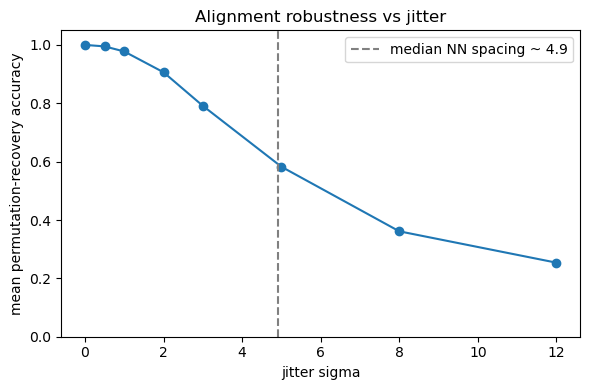

In [9]:
jitters = [0.0, 0.5, 1.0, 2.0, 3.0, 5.0, 8.0, 12.0]
mean_accs = []
for j in jitters:
    lyt, tp, _ = make_layouts(n_det=100, K=8, jitter=j, ref_idx=REF_IDX, seed=2)
    _, p = align_to_reference(lyt, REF_IDX)
    mean_accs.append(recovery_accuracy(p, tp, REF_IDX).mean())

for j, a in zip(jitters, mean_accs):
    print(f"jitter={j:5.1f}  mean recovery accuracy={a:.3f}")

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(jitters, mean_accs, "o-")
ax.axvline(np.median(nn), ls="--", c="grey",
           label=f"median NN spacing ~ {np.median(nn):.1f}")
ax.set_xlabel("jitter sigma")
ax.set_ylabel("mean permutation-recovery accuracy")
ax.set_title("Alignment robustness vs jitter")
ax.set_ylim(0, 1.05)
ax.legend()
plt.tight_layout()
plt.show()

## Test 4 — Visualise before/after alignment

Pick one shuffled+jittered run and draw arrows from the reference position
(column `i`) to where that column lands **before** alignment (wrong, because of
the shuffle) and **after** alignment (should point to the matching reference
detector). Short arrows after alignment = good matching.

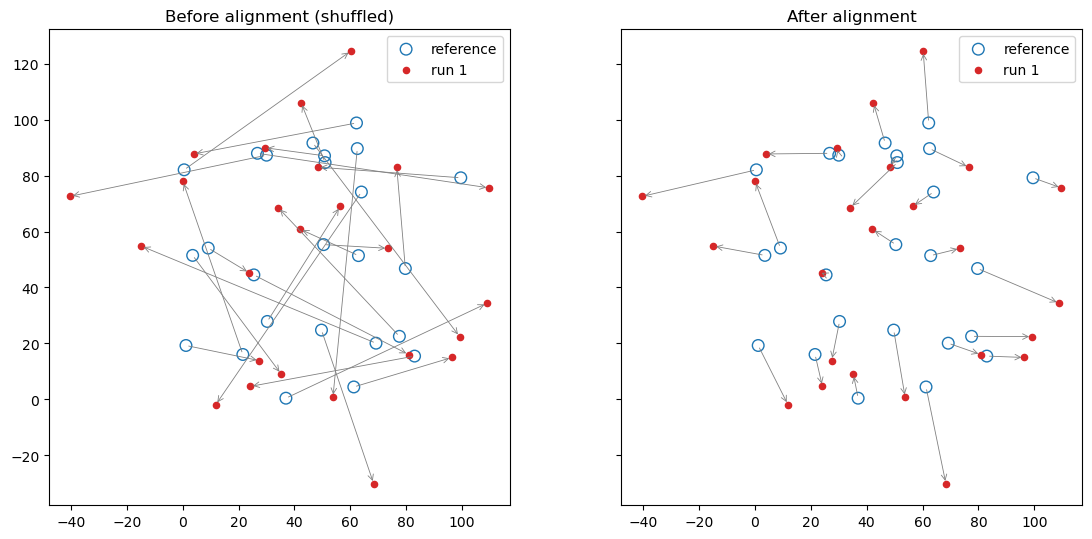

run 1 recovery accuracy: 0.600
mean arrow length before: 55.91
mean arrow length after : 17.46


In [12]:
# small layout so arrows are legible
lyt_v, tp_v, ref_v = make_layouts(n_det=25, K=4, jitter=20.5, ref_idx=0, seed=7)
aligned_v, perms_v = align_to_reference(lyt_v, 0)

k = 1  # the run we visualise
before = lyt_v[k]       # column i = arbitrary (shuffled) detector
after = aligned_v[k]    # column i = detector matched to reference[i]

fig, axes = plt.subplots(1, 2, figsize=(12, 5.5), sharex=True, sharey=True)
for ax, pts, title in [(axes[0], before, "Before alignment (shuffled)"),
                       (axes[1], after, "After alignment")]:
    ax.scatter(ref_v[:, 0], ref_v[:, 1], s=70, facecolors="none",
               edgecolors="tab:blue", label="reference")
    ax.scatter(pts[:, 0], pts[:, 1], s=20, c="tab:red", label=f"run {k}")
    for i in range(ref_v.shape[0]):
        ax.annotate("", xy=(pts[i, 0], pts[i, 1]),
                    xytext=(ref_v[i, 0], ref_v[i, 1]),
                    arrowprops=dict(arrowstyle="->", color="grey", lw=0.6))
    ax.set_title(title)
    ax.set_aspect("equal")
    ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

acc_k = recovery_accuracy(perms_v, tp_v, 0)[k]
print(f"run {k} recovery accuracy: {acc_k:.3f}")
print(f"mean arrow length before: "
      f"{np.linalg.norm(before - ref_v, axis=-1).mean():.2f}")
print(f"mean arrow length after : "
      f"{np.linalg.norm(after - ref_v, axis=-1).mean():.2f}")